# Aplicação Estatística a problemas reais da Biologia

Nesta aula vamos analisar o crescimento de **6 microrganismos** em cultura pura, extrair parâmetros biológicos das curvas de crescimento, e aplicar testes estatísticos para comparar os organismos entre si.

**Organismos em estudo:**

| Organismo | Tipo | Patogenicidade | Ambiente natural |
|---|---|---|---|
| *E. coli* K12 | Bactéria Gram− | Comensal | Intestino humano |
| *Salmonella enterica* | Bactéria Gram− | Patogénico | Intestino, alimentos |
| *L. acidophilus* | Bactéria Gram+ | Comensal/probiótico | Intestino, vagina |
| *C. difficile* | Bactéria Gram+ | Patogénico | Intestino (oportunista) |
| *S. cerevisiae* | Levedura | Comensal/probiótico | Intestino humano, alimentos, solo |
| *C. albicans* | Levedura | Patogénico (oportunista) | Intestino, vagina |

## Curvas de Crescimento

O crescimento microbiano segue um padrão **sigmoidal** bem caracterizado, com fases distintas: **lag**, **exponencial**, **estacionária** e **declínio**. A análise quantitativa destas curvas permite extrair parâmetros biológicos que descrevem o comportamento de cada cultura.

---

### Parâmetros-chave

| Parâmetro | Símbolo | Significado biológico | Unidade |
|---|---|---|---|
| Plateau | **A** | Densidade ótica máxima atingida (capacidade de carga) | OD600 |
| Taxa de crescimento máxima | **μ_max** | Inclinação máxima da curva — quão rápido as células se dividem | OD/h |
| Fase lag | **λ** | Tempo que a cultura demora a iniciar o crescimento exponencial | horas |

---

### Porquê estes parâmetros?

Estes três parâmetros permitem responder a questões práticas importantes, como:
- **Segurança alimentar:** Quanto tempo demora um patogénico a começar a multiplicar-se num alimento? (λ)
- **Produção industrial:** Qual o organismo que atinge maior biomassa? (A)
- **Competição entre espécies:** Quem cresce mais rápido e pode dominar uma co-cultura? (μ_max)


In [1]:
# instalar Pacotes se necessário
!pip install numpy pandas matplotlib scipy statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [135]:
# Importar Pacotes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# FASE 1 — Carregar e visualizar os dados

Antes de qualquer cálculo, é fundamental **olhar para os dados**. Vamos carregar o ficheiro CSV com as leituras de OD600 ao longo do tempo para as 6 estirpes (3 réplicas cada).

### 1.1 Abrir as medições de crescimento microbiano

O ficheiro `crescimento_microbiano.csv` contém leituras de **densidade ótica a 600 nm (OD600)** ao longo de 24 horas para as 6 estirpes, com 3 réplicas biológicas cada.

A OD600 é uma medida indireta da **concentração de células** em suspensão — quanto mais células, mais luz é dispersa e maior o valor de OD.

**Estrutura dos dados:**
- Cada **linha** = uma réplica de uma estirpe
- Cada **coluna** numérica = um ponto temporal (em horas)
- Colunas `Strain` e `Replicate` = identificação da amostra


In [5]:
# Carregar o CSV numa dataframe pandas
df = pd.read_csv("crescimento_microbiano.csv")
df

,Strain,Replicate,0,0.5,1,1.5,2,2.5,3,3.5,...,5,6,7,8,9,10,12,16,20,24
0,E_coli_K12,R1,0.142,0.110,0.150,0.196,0.290,1.106,2.092,2.571,...,2.872,2.891,2.929,2.822,2.831,2.889,2.867,2.933,2.872,2.847
1,E_coli_K12,R2,0.002,0.017,0.000,0.000,0.204,0.956,1.928,2.399,...,2.884,2.810,2.760,2.855,2.753,2.824,2.716,2.747,2.824,2.851
2,E_coli_K12,R3,0.000,0.000,0.000,0.000,0.073,0.964,1.824,2.239,...,2.655,2.739,2.763,2.758,2.670,2.696,2.728,2.760,2.688,2.702
3,Salmonella_enterica,R1,0.000,0.000,0.026,0.000,0.014,0.148,0.727,1.537,...,2.531,2.407,2.596,2.562,2.543,2.563,2.459,2.548,2.576,2.632
4,Salmonella_enterica,R2,0.000,0.000,0.033,0.004,0.000,0.184,0.793,1.596,...,2.462,2.494,2.598,2.599,2.587,2.575,2.516,2.566,2.570,2.547
5,Salmonella_enterica,R3,0.195,0.270,0.184,0.188,0.176,0.251,0.975,1.739,...,2.685,2.753,2.713,2.832,2.813,2.815,2.730,2.845,2.705,2.805
6,L_acidophilus,R1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.486,1.116,1.420,1.715,1.876,1.803,1.910,1.914,1.940
7,L_acidophilus,R2,0.086,0.178,0.167,0.164,0.169,0.118,0.163,0.167,...,0.307,0.693,1.359,1.684,1.993,2.120,2.093,2.199,2.172,2.193
8,L_acidophilus,R3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.051,0.669,1.138,1.470,1.681,1.866,1.903,1.967,1.956,1.929
9,C_difficile,R1,0.232,0.286,0.351,0.319,0.246,0.317,0.327,0.264,...,0.300,0.620,1.086,1.587,1.945,2.051,2.278,2.428,2.433,2.434


In [136]:
print("Boas práticas: ")

print("Verifica as primeiras linhas do DataFrame:")
print()

Boas práticas: 
Verifica as primeiras linhas do DataFrame:



#### **Questão**

- Quantas medições temos no total? (linhas × colunas de tempo)

  
  **Resposta**: São 18 linhas e 22 colunas de tempo.
  
- Os valores de OD no tempo 0 são todos iguais? O que poderia explicar pequenas diferenças?

  
  **Resposta**: Não são iguais. Explica-se pela diferença na quantidade de células no início, isto é, quanto maior o número de células em suspensão maior a dispersão de luz e maior a densidade óptica.

In [5]:
print("Verificar quais as condições a analisar")
print("Estirpe:C_difficile")
print(df['Strain'].unique())

#print("Réplicas por estirpe:")
#print(XXX)


Verificar quais as condições a analisar
Estirpe:C_difficile
['E_coli_K12' 'Salmonella_enterica' 'L_acidophilus' 'C_difficile'
 'S_cerevisiae' 'C_albicans']


In [6]:
réplicas = df['Replicate'].value_counts()

In [7]:
réplicas

Replicate
R1    6
R2    6
R3    6
Name: count, dtype: int64

In [8]:
 df['Replicate'].unique()

array(['R1', 'R2', 'R3'], dtype=object)

In [9]:
 df['Strain'].value_counts()

Strain
E_coli_K12             3
Salmonella_enterica    3
L_acidophilus          3
C_difficile            3
S_cerevisiae           3
C_albicans             3
Name: count, dtype: int64

#### **Questão**
- No total quantas estirpes vamos analisar?

  
**Resposta**: No total foram analisadas  6 estirpes.

- E quantas réplicas temos por análise?
  
  **Resposta**: Analisamos 3 réplicas por estirpe.

In [10]:
print("\nEstatísticas descritivas:")
print(df.describe()) #describe


Estatísticas descritivas:
               0        0.5          1        1.5          2        2.5  \
count  18.000000  18.000000  18.000000  18.000000  18.000000  18.000000   
mean    0.062778   0.068000   0.068222   0.075778   0.094833   0.240500   
std     0.082119   0.093634   0.096481   0.096642   0.095648   0.366672   
min     0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   
25%     0.000000   0.000000   0.000000   0.000000   0.000000   0.002250   
50%     0.001000   0.020500   0.022500   0.022500   0.082000   0.094500   
75%     0.113000   0.101500   0.134500   0.153000   0.165750   0.234250   
max     0.232000   0.286000   0.351000   0.319000   0.290000   1.106000   

               3        3.5          4        4.5          5          6  \
count  18.000000  18.000000  18.000000  18.000000  18.000000  18.000000   
mean    0.511278   0.715778   0.858000   0.919222   0.951389   1.096889   
std     0.727000   0.976802   1.147606   1.211050   1.265501   1.176608 

In [74]:
c_difficile = df [df['Strain'] == 'C_difficile']
print(c_difficile.describe())

              0       0.5         1       1.5         2       2.5         3  \
count  3.000000  3.000000  3.000000  3.000000  3.000000  3.000000  3.000000   
mean   0.105333  0.120667  0.130667  0.166667  0.117000  0.105667  0.136667   
std    0.117462  0.148140  0.191912  0.159982  0.123438  0.183020  0.169977   
min    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
25%    0.042000  0.038000  0.020500  0.090500  0.052500  0.000000  0.041500   
50%    0.084000  0.076000  0.041000  0.181000  0.105000  0.000000  0.083000   
75%    0.158000  0.181000  0.196000  0.250000  0.175500  0.158500  0.205000   
max    0.232000  0.286000  0.351000  0.319000  0.246000  0.317000  0.327000   

            3.5         4       4.5         5         6         7         8  \
count  3.000000  3.000000  3.000000  3.000000  3.000000  3.000000  3.000000   
mean   0.101333  0.145333  0.122667  0.174333  0.384667  0.893000  1.303667   
std    0.142286  0.160752  0.174947  0.108969  0.23

#### **Questão**
- Como varia o desvio padrão com o tempo?

  **Resposta** : O desvio padrão varia ao longo do tempo de forma crescente primeiro (do tempo 0 até ao tempo 6) e decrescente ( do tempo 7 ao tempo 24).

### Atribuição de estirpes por grupo

Cada grupo altera a variável `estirpe` na célula seguinte para o seu organismo:

| Grupo | Organismo | Tipo |
|---|---|---|
| 1 | `E_coli_K12` | Bactéria comensal |
| 2 | `Salmonella_enterica` | Bactéria patogénica |
| 3 | `L_acidophilus` | Bactéria probiótica |
| 4 | `C_difficile` | Bactéria patogénica |
| 5 | `S_cerevisiae` | Levedura comensal |
| 6 | `C_albicans` | Levedura patogénica |




#### **Questão**
Antes de correr o código, o que esperam? 
- Um patogénico cresce mais rápido que um comensal?

- **Resposta** : Sim, porque tomando em consideração que os comensais estejam mais adaptados ao nicho hospedeiro e sem capacidade de causar danos ao mesmo, mantendo suas taxas de replicação praticamente estáveis, ao passo que as patogénicas por possuírem mecanismos de virulência criam um ambiente hostil para as comensais, diminuindo suas chances de replicação e favorecendo à sua.

  
- Uma levedura cresce mais devagar que uma bactéria?

**Resposta**: Sim, porque as bactérias enquanto estruturalmente mais simples replicam-se mais rápido, enquanto que as leveduras são células eucariotas e portanto possuem um ciclo de divisão celular mais longo e elaborado.

### 1.2 Filtrar os dados da vossa estirpe

Filtramos a dataframe de maneira a selecionar apenas as linhas correspondentes à estirpe escolhida, e removemos as colunas não numéricas (Strain, Replicate).

In [75]:
estirpe = "E_coli_K12" # defina a estirpe a analisar

df_estirpe = df[df["Strain"] == estirpe] # filtrar o dataframe para a estirpe escolhida
print(df_estirpe)

# ----Filtrar a dataframe para as colunas com dados apenas
#print('Colunas de tempo')

#columns = XXX # LISTA o nome das colunas do dataframe
#time_cols = XXX  # mantém apenas as colunas de tempo (assumindo que as 2 primeiras são 'Strain' e 'Replicate')
#print(time_cols)
                  
#print(f"DataFrame filtrado para a estirpe {estirpe}:\n{df_estirpe_time.head(5)}")

       Strain Replicate      0    0.5     1    1.5      2    2.5      3  \
0  E_coli_K12        R1  0.142  0.110  0.15  0.196  0.290  1.106  2.092   
1  E_coli_K12        R2  0.002  0.017  0.00  0.000  0.204  0.956  1.928   
2  E_coli_K12        R3  0.000  0.000  0.00  0.000  0.073  0.964  1.824   

     3.5  ...      5      6      7      8      9     10     12     16     20  \
0  2.571  ...  2.872  2.891  2.929  2.822  2.831  2.889  2.867  2.933  2.872   
1  2.399  ...  2.884  2.810  2.760  2.855  2.753  2.824  2.716  2.747  2.824   
2  2.239  ...  2.655  2.739  2.763  2.758  2.670  2.696  2.728  2.760  2.688   

      24  
0  2.847  
1  2.851  
2  2.702  

[3 rows x 22 columns]


In [51]:
c_difficile = df [df['Strain'] == 'C_difficile']
print(c_difficile.describe())
print(c_difficile)

colunas = df.columns.to_list()
colunas
tempo = colunas[2:]
print(tempo)

              0       0.5         1       1.5         2       2.5         3  \
count  3.000000  3.000000  3.000000  3.000000  3.000000  3.000000  3.000000   
mean   0.105333  0.120667  0.130667  0.166667  0.117000  0.105667  0.136667   
std    0.117462  0.148140  0.191912  0.159982  0.123438  0.183020  0.169977   
min    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
25%    0.042000  0.038000  0.020500  0.090500  0.052500  0.000000  0.041500   
50%    0.084000  0.076000  0.041000  0.181000  0.105000  0.000000  0.083000   
75%    0.158000  0.181000  0.196000  0.250000  0.175500  0.158500  0.205000   
max    0.232000  0.286000  0.351000  0.319000  0.246000  0.317000  0.327000   

            3.5         4       4.5         5         6         7         8  \
count  3.000000  3.000000  3.000000  3.000000  3.000000  3.000000  3.000000   
mean   0.101333  0.145333  0.122667  0.174333  0.384667  0.893000  1.303667   
std    0.142286  0.160752  0.174947  0.108969  0.23

### 1.3 Calcular média e desvio-padrão de todos os tempos

Para cada ponto temporal, calculamos a **média** e o **desvio-padrão** das 3 réplicas.

- A **média** dá-nos o valor central da medição
- O **desvio-padrão** indica a variabilidade entre réplicas — se é pequeno, as réplicas são consistentes


In [29]:
# --- Usa a dataframe 'df_estirpe' para calcular os valores da média

print(c_difficile)

od_mean = c_difficile[tempo].mean().values # selecionar valores e calcular média para cada tempo
print(f"Médias calculadas por cada periodo de tempo analisado:\n{od_mean}")

od_std  = c_difficile[tempo].std().values # calcular desvio-padrão para cada tempo
print(f"Desvios-padrão:\n{od_std}")

time_array = np.array(tempo, dtype=float) # criar array de tempos a das colunas de tempo
print(f"Array de tempos (horas): {time_array}")

         Strain Replicate      0    0.5      1    1.5      2    2.5      3  \
9   C_difficile        R1  0.232  0.286  0.351  0.319  0.246  0.317  0.327   
10  C_difficile        R2  0.000  0.000  0.000  0.000  0.000  0.000  0.000   
11  C_difficile        R3  0.084  0.076  0.041  0.181  0.105  0.000  0.083   

      3.5  ...      5      6      7      8      9     10     12     16     20  \
9   0.264  ...  0.300  0.620  1.086  1.587  1.945  2.051  2.278  2.428  2.433   
10  0.000  ...  0.106  0.142  0.726  1.086  1.502  1.808  1.961  1.981  2.005   
11  0.040  ...  0.117  0.392  0.867  1.238  1.640  1.861  2.057  2.255  2.193   

       24  
9   2.434  
10  2.076  
11  2.110  

[3 rows x 22 columns]
Médias calculadas por cada periodo de tempo analisado:
[0.10533333 0.12066667 0.13066667 0.16666667 0.117      0.10566667
 0.13666667 0.10133333 0.14533333 0.12266667 0.17433333 0.38466667
 0.893      1.30366667 1.69566667 1.90666667 2.09866667 2.22133333
 2.21033333 2.20666667]
Desvios-pad

In [97]:
c_difficile = df [df['Strain'] == 'C_difficile']
c_difficile

od_mean = c_difficile[tempo].mean().values.round(3)
print(f"a media calculada por periodo de tempo:{od_mean}")

od_std  = c_difficile[tempo].std().values.round(3)
print(f"o std calculada para cada tempo:{od_std}")

tempo_array = np.array(tempo, dtype = float)
print(f"Array de tempos (horas): {tempo_array}")

a media calculada por periodo de tempo:[0.105 0.121 0.131 0.167 0.117 0.106 0.137 0.101 0.145 0.123 0.174 0.385
 0.893 1.304 1.696 1.907 2.099 2.221 2.21  2.207]
o std calculada para cada tempo:[0.117 0.148 0.192 0.16  0.123 0.183 0.17  0.142 0.161 0.175 0.109 0.239
 0.181 0.257 0.227 0.128 0.163 0.225 0.215 0.198]
Array de tempos (horas): [ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   6.   7.   8.
  9.  10.  12.  16.  20.  24. ]


#### **Questão:**

Olhando para a média dos valores, consegues antever:
- quando acaba a fase de adaptação do crescimento (lag)?

  **Resposta**:A fase de adaptaçãodo crescimento acaba no tempo 6
- quando começa  afase de crescimento exponencial?

  **Resposta**: A fase de crescimento começa no tempo 6, onde acaba a fase lag.
  
- quando se inicia a fase estacinária?

 **Resposta**: A fase estacionária se inicia no tempo 12 e se mantém pelos tempos 16,20, 24.

### 1.4 Representação gráfica

Vamos representar a curva de crescimento com a média ± desvio-padrão (barras de erro), mas também todas as réplicas individualmente.


         Strain Replicate      0    0.5      1    1.5      2    2.5      3  \
9   C_difficile        R1  0.232  0.286  0.351  0.319  0.246  0.317  0.327   
10  C_difficile        R2  0.000  0.000  0.000  0.000  0.000  0.000  0.000   
11  C_difficile        R3  0.084  0.076  0.041  0.181  0.105  0.000  0.083   

      3.5  ...      5      6      7      8      9     10     12     16     20  \
9   0.264  ...  0.300  0.620  1.086  1.587  1.945  2.051  2.278  2.428  2.433   
10  0.000  ...  0.106  0.142  0.726  1.086  1.502  1.808  1.961  1.981  2.005   
11  0.040  ...  0.117  0.392  0.867  1.238  1.640  1.861  2.057  2.255  2.193   

       24  
9   2.434  
10  2.076  
11  2.110  

[3 rows x 22 columns]
Strain       C_difficile
Replicate             R1
0                  0.232
0.5                0.286
1                  0.351
1.5                0.319
2                  0.246
2.5                0.317
3                  0.327
3.5                0.264
4                  0.318
4.5             

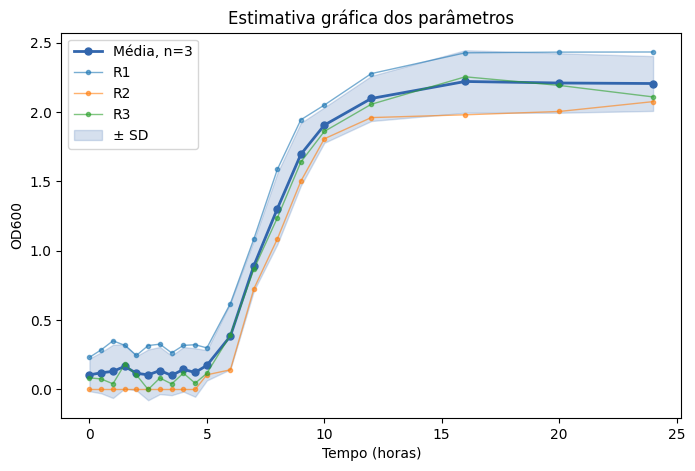

In [22]:
# --- Para o cálculo dos valores da média usa od_mean, od_std
# --- Para o cálculo dos valores das réplicas individuais usa a dataframe 'df_estirpe' e colunas de dados 'time_cols'

fig, ax = plt.subplots(figsize=(8, 5))


# ────── Curva dos valores médios de crescimento
ax.plot(tempo_array, od_mean, #X = time, Y= média de OD em cada tempo
        "o-", color="#3266ad", linewidth=2, markersize=5, label='Média, n=3')

# ────── Curva dos valores de cada réplicas individual
print(c_difficile)
for i, row in c_difficile.iterrows():
    print(row)
    ax.plot(tempo_array, row[tempo], #X = time, Y= valores de OD em CADA TEMPO
          "o-", linewidth=1, markersize=3, alpha=0.6, label=row["Replicate"]) # label usando o nome da réplica


# ────── Banda de desvio padrão
ax.fill_between(tempo_array, od_mean - od_std, od_mean + od_std,  # X = time, Y_baixo = valor mais baixo (média - std), Y_alto = valor mais alto (média + std)
               color="#3266ad", alpha=0.2, label="± SD")

ax.set_xlabel("Tempo (horas)")
ax.set_ylabel("OD600")
ax.set_title("Estimativa gráfica dos parâmetros")
ax.legend()

#mostra a imagem e fecha, permitindo a continua alteração da imagem
display(fig)
plt.close()

### **Questão**
- Conseguem identificar as fases lag, exponencial e estacionária?

  **Resposta**: Sim, estão identificadas no gráfico abaixo.
  
- Como se comparam as diferentes réplicas individualmente com a média e desvio padrão?

  **Resposta**: A média da R3 se aproxima mais da media ao longo de todo o ensaio. A R1 representa o limite superior do desvio padrão (significando um crescimento mais acentuado e maior plateu) e a R2 representa o limite inferior de crescimento mais lento e com menor plateu. Assim sendo, em relação ao desvio padrão, toda a variação da média se encontra distribuída dentro da área sombreada.

# FASE 2 — Calcular os parâmetros de crescimento

Agora vamos passar da observação ao cálculo. Para cada estirpe, vamos estimar os 3 parâmetros de crescimento a partir dos dados:

| Passo | O que vamos fazer | Parâmetro | 
|-------|-------------------|-----------|
| 2.1 | Estimar o plateau (média dos últimos pontos) | **A** |
| 2.2 | Calcular a taxa máxima de crescimento (ΔOD/Δt) | **μ_max** |
| 2.3 | Estimar a fase lag a partir do ponto de inflexão | **λ** |

Cada grupo vai analisar **um microrganismo** e no final juntamos os resultados de todos.

### 2.1 Crescimento máximo — Plateau ou Fase Estacionária (A)

O plateau (A) representa a **densidade ótica máxima** que a cultura atinge — o ponto em que o crescimento estabiliza porque os nutrientes se esgotam ou os produtos tóxicos se acumulam.

Estimamos A como a **média dos últimos pontos temporais**, onde a curva já estabilizou.

**O que determina o valor de A?**
- **Capacidade de carga do meio:** quantidade de nutrientes disponíveis
- **Tolerância a produtos metabólicos:** ácidos, etanol, toxinas que se acumulam
- **Tamanho celular:** a mesma OD600 pode corresponder a números diferentes de células conforme o organismo (bactérias são mais pequenas que leveduras)

**Questão:** 
- Se duas estirpes crescem no mesmo meio, mas uma atinge um plateau mais alto, o que pode explicar a diferença?

 **Resposta**: Essa diferença é explicada pela capacidade de adaptação de cada estirpe ao meio, as que se adaptam mais rápido (fase lag mais curta) crescem mais rápido e atingem a densidade máxima mais rápido adquirindo um plateu mais alto.

Valores selecionados: [2.22133333 2.21033333 2.20666667]

Estimativas gráficas para          Strain Replicate      0    0.5      1    1.5      2    2.5      3  \
9   C_difficile        R1  0.232  0.286  0.351  0.319  0.246  0.317  0.327   
10  C_difficile        R2  0.000  0.000  0.000  0.000  0.000  0.000  0.000   
11  C_difficile        R3  0.084  0.076  0.041  0.181  0.105  0.000  0.083   

      3.5  ...      5      6      7      8      9     10     12     16     20  \
9   0.264  ...  0.300  0.620  1.086  1.587  1.945  2.051  2.278  2.428  2.433   
10  0.000  ...  0.106  0.142  0.726  1.086  1.502  1.808  1.961  1.981  2.005   
11  0.040  ...  0.117  0.392  0.867  1.238  1.640  1.861  2.057  2.255  2.193   

       24  
9   2.434  
10  2.076  
11  2.110  

[3 rows x 22 columns]:
  Plateau (A) média ≈ 2.2127777777777777
  R1: Plateau ≈ 2.432
  R2: Plateau ≈ 2.021
  R3: Plateau ≈ 2.186


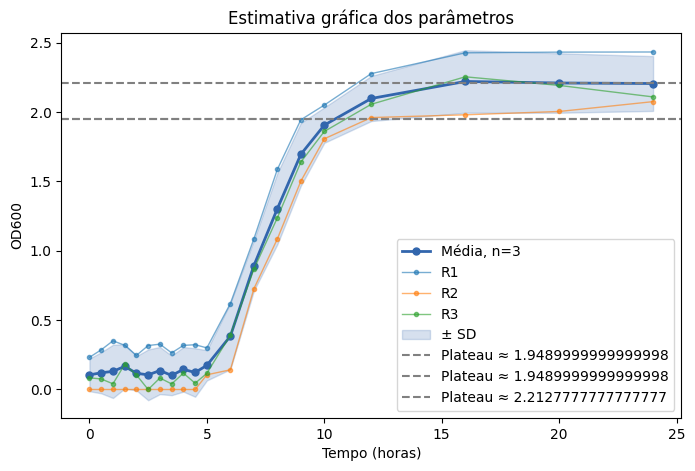

In [27]:
###### --- Para o cálculo dos valores da média usa od_mean, od_std
# --- Para o cálculo dos valores das réplicas individuais usa a dataframe 'df_estirpe' e colunas de dados 'time_cols'


# ─────────────── Plateau (A) ─────────────────────────────────────────
# ────── Calcular o plateu médio
valor_incial_A = 17 # em que valor a reta entra em A?
valores_A = od_mean[valor_incial_A:] # selecionar os valores a partir do tempo onde a curva parece estabilizar (usar o array de médias)
print(f"Valores selecionados: {valores_A}")

A_estimado = valores_A.mean() # calcular a média dos valores para obter a estimativa do plateau
print(f"\nEstimativas gráficas para {c_difficile}:")
print(f"  Plateau (A) média ≈ {A_estimado}")

#visualiza o valor médio do plateau no gráfico
ax.axhline(A_estimado, color="gray", linestyle="--", label=f"Plateau ≈ {A_estimado}") 
ax.legend()

# ────── Calcular o plateau para cada réplica individualmente
for i, row in c_difficile.iterrows():      # loop por cada réplica usando df_estirpe
    od_rep = row[tempo].values         # seleciona as colunas de valores → guarda os values de OD
    od_A_rep =od_rep[valor_incial_A:]                       # valores de A
    A_rep = od_A_rep.mean()                          # média → estimativa do plateau
    print(f"  {row['Replicate']}: Plateau ≈ {A_rep:.3f}")


display(fig)

plt.close()

### 2.2 Taxa de crescimento máxima (μ_max)

A taxa de crescimento máxima corresponde à **inclinação máxima** da curva — o momento em que as células se estão a dividir mais rapidamente (fase exponencial).

Calculamos μ_max como a derivada numérica da curva:

$$\mu_{max} = \max\left(\frac{\Delta OD}{\Delta t}\right)$$

Ou seja, para cada par de pontos consecutivos calculamos a variação de OD por hora (ΔOD/Δt) e ficamos com o **valor máximo**.

**O que influencia μ_max?**
- **Tipo de divisão celular:** bactérias (fissão binária, ~20 min) vs leveduras (gemulação, ~90 min)
- **Meio de cultura:** disponibilidade de nutrientes, temperatura, pH
- **Metabolismo:** aeróbio vs anaeróbio, fermentativo vs respiratório


Taxa de crescimento (ΔOD): [ 0.01533333  0.01        0.036      -0.04966667 -0.01133333  0.031
 -0.03533333  0.044      -0.02266667  0.05166667  0.21033333  0.50833333
  0.41066667  0.392       0.211       0.192       0.12266667 -0.011
 -0.00366667]
Intervalos de tempo (Δt): [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 1.  1.  1.  1.  1.  2.  4.  4.
 4. ]
Taxa de crescimento por hora (ΔOD/Δt): [ 0.03066667  0.02        0.072      -0.09933333 -0.02266667  0.062
 -0.07066667  0.088      -0.04533333  0.10333333  0.21033333  0.50833333
  0.41066667  0.392       0.211       0.096       0.03066667 -0.00275
 -0.00091667]
0.5083333333333335
O crescimento máximo de 0.5083333333333335 OD/h ocorre no tempo de 6.0 horas
  R1: μ_max ≈ 0.5009999999999999 OD/h
  R2: μ_max ≈ 0.584 OD/h
  R3: μ_max ≈ 0.475 OD/h
Estimativas gráficas para          Strain Replicate      0    0.5      1    1.5      2    2.5      3  \
9   C_difficile        R1  0.232  0.286  0.351  0.319  0.246  0.317  0.327   
10  C_difficile 

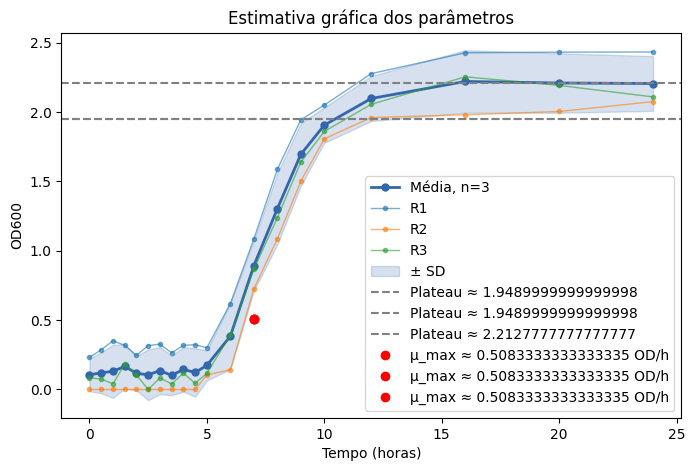

In [42]:
# --- Para o cálculo dos valores da média usa od_mean, od_std
# --- Para o cálculo dos valores das réplicas individuais usa a dataframe 'df_estirpe' e colunas de dados 'time_cols'


# ─────────────── Taxa máxima (mu) ────────────────────────────────────

# ────── Calcular o mu médio
# -- np (numpy é usado para trabalhar com arrays e fazer operações amtemáticas)
dod = np.diff(od_mean) # calcular a diferença entre os valores de OD para obter a taxa de crescimento
print(f"Taxa de crescimento (ΔOD): {dod}")

dt = np.diff(tempo_array) # calcular intervalo de tempo
print(f"Intervalos de tempo (Δt): {dt}")

dod_dt = dod/dt # aplicar a fórmula da taxa de crescimento (ΔOD/Δt)
print(f"Taxa de crescimento por hora (ΔOD/Δt): {dod_dt}")

mu_estimado  = dod_dt.max() # encontrar o valor máximo de μ_max no ARRAY de valores
print(mu_estimado)


idx_max = np.argmax(dod_dt) # encontrar o índice no array no valor máximo tipo encontrar a posição 
tempo_mu_max  = tempo_array[idx_max] # para identificar o tempo correspondente
print(f"O crescimento máximo de {mu_estimado} OD/h ocorre no tempo de {tempo_mu_max} horas")

# ────── Calcular mu para cada réplica individualmente
for i, row in c_difficile.iterrows():
    od_rep      =  row[tempo].values # extrair os valores de OD da réplica
    dod_dt_rep  = np.diff(od_rep)/dt # calcular a taxa de crescimento da réplica
    mu_rep      = dod_dt_rep.max()# estimar μ_max da réplica
    print(f"  {c_difficile.loc[i, 'Replicate']}: μ_max ≈ {mu_rep} OD/h")


# --- plot no gráfico
ax.plot(tempo_array[idx_max] +1, dod_dt[idx_max], "o", color="red", 
       label=f"μ_max ≈ {mu_estimado} OD/h")
ax.legend()

print(f"Estimativas gráficas para {c_difficile}:")
print(f"  Plateau (A)  ≈ {A_estimado:.3f}")
print(f"  μ_max        ≈ {mu_estimado:.3f} OD/h")

display(fig)
plt.close()

### 2.3 Estimativa da Fase Lag (λ)
#A fase lag é calculada a partir do ponto de inflexão da curva:
$$\lambda = t_{inf} - \frac{OD_{inf} - OD_0}{\mu_{max}}$$

Onde:
- **lambda** — tempo da fase lag (se λ = 2 horas, significa que a cultura ficou cerca de 2 horas em adaptação antes de crescer rapidamente)
- **t_inf** — tempo no ponto de inflexão (onde o crescimento é mais rápido)
- **OD_inf** — valor de OD nesse ponto
- **OD_0** — valor de OD no tempo zero
- **μ_max** — taxa de crescimento máxima (calculada no passo anterior)

Ouuuu....

Podemos estimar quando a OD ultrapassa o valor de inicial.

#### **Questão:** 
- Um organismo com uma fase lag longa é vantajoso ou desvantajoso? Depende do contexto?

  **Resposta** : Depende do contexto, se forem bactérias patogénicas é vantajoso porque uma fase lag mais longa significaria taxa de crescimento relativamente baixa. E se forem comensais seria desvantajoso porque uma fase lag mais longa ia signicar baixa taxa de crescimento sendo estas benéficas para o hospedeiro.

Limite de crescimento em fase Lag: 0.20533333333333334
Valores acima do threshold: [False False False False False False False False False False False  True
  True  True  True  True  True  True  True  True]
Tempos acima do crescimento lag: [ 6.  7.  8.  9. 10. 12. 16. 20. 24.]
Tempo que o crescimento sai de fase lag: 6.0
6.0
6.0
6.0
Estimativas gráficas para E_coli_K12:
  Plateau (A)  ≈ 2.2127777777777777
  μ_max        ≈ 0.5083333333333335 OD/h
  Fase lag     ≈ 6.0 h


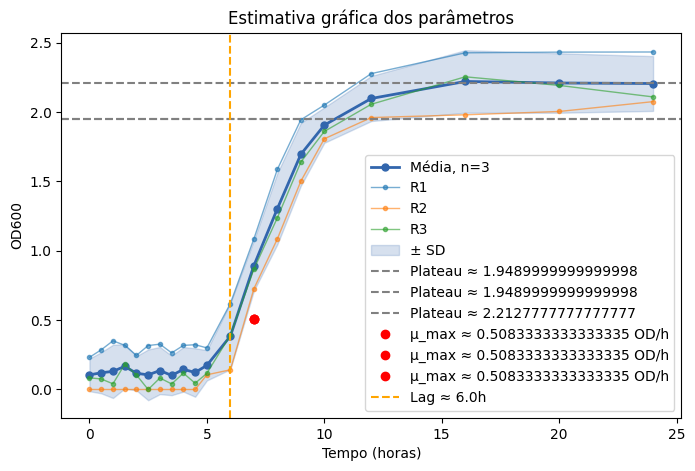

In [70]:
# --- Para o cálculo dos valores da média usa od_mean, od_std
# --- Para o cálculo dos valores das réplicas individuais usa a dataframe 'df_estirpe' e colunas de dados 'time_cols'

# ────── Calcular lam da média
threshold = od_mean[0] + 0.1 # OD inicial + margem para ignorar ruído
print(f"Limite de crescimento em fase Lag: {threshold}")

array_valores_acima_threshold = od_mean> threshold # cria um array booleano (True/False) dos valores de od_mean acima do threshold defnido
print(f"Valores acima do threshold: {array_valores_acima_threshold}")

valores_tempo_acima_threshold = tempo_array[array_valores_acima_threshold] # Retira os valores de tempo onde True
print(f"Tempos acima do crescimento lag: {valores_tempo_acima_threshold}")

lam_estimado =valores_tempo_acima_threshold [0] # primeiro tempo onde OD ultrapassa o threshold
print(f"Tempo que o crescimento sai de fase lag: {lam_estimado}")

# ────── Calcular lam para cada réplica individualmente
for i, row in c_difficile.iterrows():
    lam_rep = row[tempo].values
    valores_tempo_acima = lam_rep > threshold
    valores_tempo_acima_threshold = tempo_array[array_valores_acima_threshold]
    cada_lam_rep =  valores_tempo_acima_threshold[0]
    print(cada_lam_rep )
#print(f"  {df_estirpe.loc[i, 'Replicate']}: Lag ≈ {lam_rep} h")

ax.axvline(lam_estimado, color="orange", linestyle="--", label=f"Lag ≈ {lam_estimado}h") # representar graficamente
ax.legend()

print(f"Estimativas gráficas para {estirpe}:")
print(f"  Plateau (A)  ≈ {A_estimado}")
print(f"  μ_max        ≈ {mu_estimado} OD/h")
print(f"  Fase lag     ≈ {lam_estimado} h")

display(fig)
plt.close()

In [50]:
tempo_array[array_valores_acima_threshold]

array([ 6.,  7.,  8.,  9., 10., 12., 16., 20., 24.])

In [49]:
lam_rep = row[tempo].values
lam_rep

array([0.084, 0.076, 0.041, 0.181, 0.105, 0.0, 0.083, 0.04, 0.118, 0.045,
       0.117, 0.392, 0.867, 1.238, 1.64, 1.861, 2.057, 2.255, 2.193, 2.11],
      dtype=object)

# FASE 3 — Comparar o crescimento das diferentes estirpes

### 3.1 Tabela resumo dos parâmetros de crescimento

Depois de estimados os parâmetros para todas as estirpes, compilamos os resultados numa tabela com a **média ± desvio-padrão** (3 réplicas) de cada parâmetro:

| Parâmetro | O que representa | Como foi estimado |
|---|---|---|
| **A** (mean ± sd) | Plateau — densidade máxima atingida | Média dos últimos 5 pontos temporais |
| **μ_max** (mean ± sd) | Taxa de crescimento máxima | Máximo de ΔOD/Δt na fase exponencial |
| **λ** (mean ± sd) | Fase lag — tempo até iniciar crescimento | Fórmula: λ = t_inf − (OD_inf − OD₀) / μ_max |

A tabela resultante terá este formato — **uma linha por estirpe, com média e desvio-padrão de cada parâmetro**:

| Strain | Replicate | A_mean | A_sd | mu_mean | mu_sd | lam_mean | lam_sd |
|---|---|---|---|---|---|---|---|
| C_albicans | ... | ... | ... | ... | ... | ... | ... |
| C_difficile | ... | ... | ... | ... | ... | ... | ... |
| E_coli_K12 | ... | ... | ... | ... | ... | ... | ... |
| L_acidophilus | ... | ... | ... | ... | ... | ... | ... |
| S_cerevisiae | ... | ... | ... | ... | ... | ... | ... |
| Salmonella_enterica | ... | ... | ... | ... | ... | ... | ... |



In [76]:
# --- Para o cálculo de todos os dados usa a dataframe 'df_estirpe' e colunas de dados 'time_cols'

#────── Criar dataframe vazia para guardar os resultados
df_resultados = pd.DataFrame(columns = ["Strain", "Replicate", "A", "mu", "lam"])

# #────── Criar função para calcular os diferentes parâmetros de crescimento
def calcular_parametros(t, od): # cria função para calcular os parÂmetros de crescimento
    
     # Plateau — média dos últimos 20% dos pontos
    n_plateau = int(0.2 * len(od))
    A = od[-n_plateau:].mean()

    # derivada numerica(diferenças finitas)
    dod_dt = np.diff(od)/np.diff(t)
     # mu máximo -- valor maximo da derivada
    idx_max = np.argmax(dod_dt)
    mu      = dod_dt[idx_max]
    
     # Fase lag — threshold
    threshold = od[0] + 0.1
    lam = t[od>threshold][0]
  
    return A, mu, lam

# #────── Calcular e armazenar os parâmetros de crescimento para todas as estirpes
for estirpe in df['Strain'].unique():
    #print(estirpe)# iterar por estirpe
    df_estirpe = df[df['Strain'] == estirpe]
    #print(df_estirpe)
    df_estirpe_time = df_estirpe[tempo] # manter apenas colunas com valores de crescimento
    print(df_estirpe_time)

    for i, row in df_estirpe_time.iterrows(): # iterar por réplica
    
        od_rep = row.values # valores de OD da linha 
        print(tempo_array)
        print(od_rep)
        A, mu, lam = calcular_parametros(tempo_array, od_rep)
        
        #         #guardar resultados
        df_resultados.loc[i, "Strain"]    = estirpe
        df_resultados.loc[i, "Replicate"] = df_estirpe.loc[i, "Replicate"]
        df_resultados.loc[i, "A"] = A
        df_resultados.loc[i, "mu"] = mu
        df_resultados.loc[i, "lam"] = lam


print("Parâmetros por réplica:")
print(df_resultados)

# #────── Colapsar em valores médios, calculando o desvio padrão
df_resumo = df_resultados.groupby("Strain").agg(  #agrupar as diferentes linhas pela coluna strain, agregando...
    A_mean=("A", "mean"), A_sd=("A", "std"), # coluna A_mean em que agregamos os valores de A pela média e coluna A_std em que agregamos os valores de A pelo desvio padrão
    mu_mean=("mu", "mean"), mu_sd=("mu", "std"), # repete para mu
    lam_mean=("lam", "mean"), lam_sd=("lam", "std") # repete para lam
).round(3)
print("\nResumo (média ± SD por estirpe):")
print(df_resumo)

       0    0.5     1    1.5      2    2.5      3    3.5      4    4.5      5  \
0  0.142  0.110  0.15  0.196  0.290  1.106  2.092  2.571  2.741  2.886  2.872   
1  0.002  0.017  0.00  0.000  0.204  0.956  1.928  2.399  2.647  2.725  2.884   
2  0.000  0.000  0.00  0.000  0.073  0.964  1.824  2.239  2.575  2.634  2.655   

       6      7      8      9     10     12     16     20     24  
0  2.891  2.929  2.822  2.831  2.889  2.867  2.933  2.872  2.847  
1  2.810  2.760  2.855  2.753  2.824  2.716  2.747  2.824  2.851  
2  2.739  2.763  2.758  2.670  2.696  2.728  2.760  2.688  2.702  
[ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   6.   7.   8.
  9.  10.  12.  16.  20.  24. ]
[0.142 0.11  0.15  0.196 0.29  1.106 2.092 2.571 2.741 2.886 2.872 2.891
 2.929 2.822 2.831 2.889 2.867 2.933 2.872 2.847]
[ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   6.   7.   8.
  9.  10.  12.  16.  20.  24. ]
[2.000e-03 1.700e-02 0.000e+00 0.000e+00 2.040e-01 9.560e-01 1.928e+00
 2.399e+0

 **Questão:** 
- Qual a estirpe com maior variabilidade (SD alto) em cada parâmetro? O que pode explicar isso?

  
  **Resposta** :  C_difficile é a estirpe com maior variabilidade experimental especialmente na fase lag, sugerindo um comportamento menos consistente entre as réplicas.

### 3.1 Simulação das curvas de crescimento — Modelo de Gompertz

Tendo os 3 parâmetros estimados (A, μ_max, λ) para cada estirpe, podemos reconstruir a curva de crescimento completa usando o **modelo de Gompertz modificado**:

$$OD(t) = A \cdot \exp\left(-\exp\left(\frac{\mu_{max} \cdot e}{A} \cdot (\lambda - t) + 1\right)\right)$$

Isto permite-nos **sobrepor todas as estirpes no mesmo gráfico** e comparar visualmente.

| Parâmetro | Símbolo | Unidade | Significado biológico |
|---|---|---|---|
| Medida de Crescimento | OD(t) | h | OD da população de microrganismos no tempo \(t\)|
| Tempo | t | h | Variável independente — o tempo decorrido desde o início do ensaio. |
| Número de Euler | e | — | Constante matemática (≈ 2,718).|

Fórmula:
- A estrutura é uma **exponencial dupla** (exp dentro de exp), o que gera a forma sigmoide assimétrica característica.
- O termo **e** na fórmula é o número de Euler (≈ 2,718), e aparece como fator de escala que garante que μ_max corresponda exatamente à taxa máxima de crescimento — é uma consequência da derivação matemática do modelo, não um parâmetro ajustável.
- O argumento interno, **(μ_max · e / A) · (λ − t) + 1**, controla a transição entre as fases.
- Quando **t ≪ λ**, (λ − t) é grande e positivo, a exponencial interna é muito grande, e a exponencial externa tende a zero — a população ainda não cresceu.
- Quando **t ≫ λ**, (λ − t) torna-se muito negativo, a exponencial interna tende a zero, e OD(t) tende a A — a população atingiu o máximo.
- A transição entre estes extremos dá-nos a **fase exponencial**.

                       A_mean   A_sd   mu_mean  mu_sd  lam_mean  lam_sd
Strain                                                                 
C_albicans           1.535417  0.039  0.257333  0.032       8.0   0.000
C_difficile           2.18425  0.196      0.52  0.057       4.0   2.646
E_coli_K12           2.794583  0.081  1.899333  0.103  2.166667   0.289
L_acidophilus         1.99825  0.146     0.638  0.025       5.5   0.866
S_cerevisiae          2.21275  0.046     0.421  0.057  6.666667   0.577
Salmonella_enterica  2.624917  0.127  1.584667  0.050  2.666667   0.289
Linha temporal criada: [ 0.          0.12060302  0.24120603  0.36180905  0.48241206  0.60301508
  0.72361809  0.84422111  0.96482412  1.08542714  1.20603015  1.32663317
  1.44723618  1.5678392   1.68844221  1.80904523  1.92964824  2.05025126
  2.17085427  2.29145729  2.4120603   2.53266332  2.65326633  2.77386935
  2.89447236  3.01507538  3.13567839  3.25628141  3.37688442  3.49748744
  3.61809045  3.73869347  3.85929648

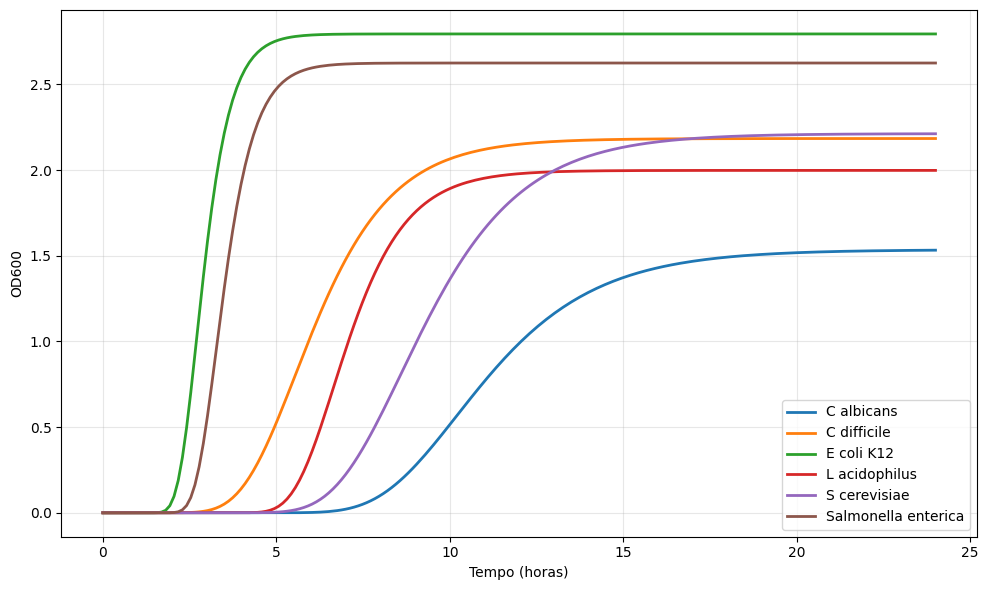

In [95]:
# Para a simulação usa a dataframe df_resumo
print(df_resumo)

# ────── Cria o gráfico
fig_all, ax_all = plt.subplots(figsize=(10, 6))

# ────── Função que faz a simulação da curva por estirpe
def gompertz(t, A, mu, lam):
    return A * np.exp(-np.exp((mu*np.e/A) * (lam - t) +1)) #Tenta completar a fórmula. Lembra-te que o np permite operações matemáticas (np.exp, np.e)
    
#---np.linspace(start, stop, num) — cria um array de num valores igualmente espaçados entre start e stop.
t_curva = np.linspace(0, tempo_array[-1], 200)
print(f"Linha temporal criada: {t_curva}")

# ──────simula a curva por cada estirpe
for estirpe in df_resumo.index.unique():       #onde estão as estirpes detalhadas?
   params   = df_resumo.loc[estirpe]        #retira os valores da estirpe da df_resumo
   print(params)                                      #retira os valores da estirpe da df_resumo
   od_curva = gompertz(t_curva,params['A_mean'], params['mu_mean'], params['lam_mean'])                               #insere os valores necessários para a função
   ax_all.plot(t_curva, od_curva, linewidth=2, label=estirpe.replace("_", " "))   
#plota a linha no gráfico - X = tempo, Y = ods calculados por gompertz

ax_all.set_xlabel("Tempo (horas)")
ax_all.set_ylabel("OD600")
ax_all.legend()
ax_all.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **Questão:** 

- Quem arranca primeiro? (λ mais curto = curva desloca-se para a esquerda)

**Resposta** quem arranca primeiro é o E_coli_K12

- Quem cresce mais rápido? (μ_max maior = curva mais íngreme)

**Resposta**: Quem cresce mais rapido é E_coli_K12

- Quem atinge maior densidade? (A maior = plateau mais alto)

**Resposta**: Quem atinge maior densidade é a E_coli_K12

- Olhando para o gráfico, consigam identificar os dois grandes grupos (bactérias vs leveduras). O que os distingue?

**Resposta**: As bactérias têm a fase lag mais curta, crescimento exponencial rápido, μ elevado, atingem rapidamente o plateau e, curvas mais inclinadas. Enquanto que as leveduras têm a fase lag mais longa, crescimento mais lento, μ mais baixo; curvas mais suaves, e atingem o plateau mais tarde. Eles destinguem-se porque as bactérias possuem divisão celular mais rápida e metabolismo geralmente mais eficiente em meios ricos, enquanto que as leveduras são organismos eucarióticos mais complexos, apresentando crescimento mais lento e maior tempo de adaptação.

### 3.2 Visualização comparativa de parâmetros de crescimento

Para facilitar a comparação dos parâmetros de crescimento, é possivel criar visualização de gráfico de barras de todas as estirpes.

                       A_mean   A_sd   mu_mean  mu_sd  lam_mean  lam_sd
Strain                                                                 
C_albicans           1.535417  0.039  0.257333  0.032       8.0   0.000
C_difficile           2.18425  0.196      0.52  0.057       4.0   2.646
E_coli_K12           2.794583  0.081  1.899333  0.103  2.166667   0.289
L_acidophilus         1.99825  0.146     0.638  0.025       5.5   0.866
S_cerevisiae          2.21275  0.046     0.421  0.057  6.666667   0.577
Salmonella_enterica  2.624917  0.127  1.584667  0.050  2.666667   0.289
lista de estirpes: Index(['C_albicans', 'C_difficile', 'E_coli_K12', 'L_acidophilus',
       'S_cerevisiae', 'Salmonella_enterica'],
      dtype='object', name='Strain')


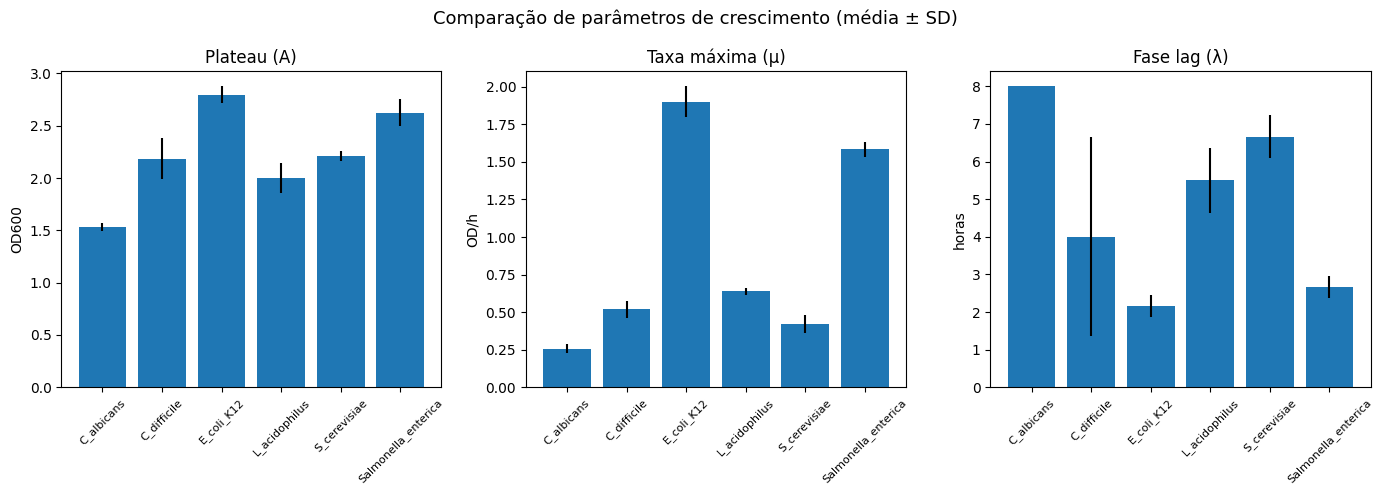

In [107]:
#  Para a visualização usa a dataframe 'df_resumo'

print(df_resumo)

# ──────Cria figura com espaço para 3 gráficos
fig_bar, ax_bar = plt.subplots(1, 3, figsize=(14, 5))

# --- No params_plot definimos que o que queremos ver em cada gráfico
# --- mean_col, sd_col, titulo, unidade 
params_plot = [
    ("A_mean",   "A_sd",   "Plateau (A)",    "OD600"),
    ("mu_mean",  "mu_sd",  "Taxa máxima (µ)", "OD/h"),
    ("lam_mean", "lam_sd", "Fase lag (λ)",    "horas"),
]

estirpes = df_resumo.index # retira as estirpes da df_resumo - index
print(f"lista de estirpes: {estirpes}")

# ────── Criar um gráfico de barras para cada parâmetro e cada estirpe
# --- O zip vai retirar os todos os valores em ax_bar e params_plot
for ax, (mean_col, sd_col, titulo, unidade) in zip(ax_bar, params_plot):
    #media_col= df_resumo.filter(endswith == 'mean')
    #valores = media_col.values
    valores = df_resumo[mean_col].values #Retira da df_resumo os values da média - media_col
    erros   = df_resumo[sd_col] #Retira da df_resumo os values da média - sd_co

    bars = ax.bar(estirpes, valores, yerr=erros) # X = estirpes, Y = valores de média, yerr = valores para as barras de erro

    ax.set_xticks(range(len(estirpes)))
    ax.set_xticklabels(estirpes, fontsize=8, rotation=45)
    ax.set_title(titulo)
    ax.set_ylabel(unidade)


plt.suptitle("Comparação de parâmetros de crescimento (média ± SD)", fontsize=13)
plt.tight_layout()
plt.show()

#### **Questão:** 
- Comparem A com μ_max: os organismos que crescem mais rápido são os que atingem maior densidade?

  **Resposta** : Sim, os organismos que crescem mais rápido são os que atingem maior densidade.

### 3.3 Os parâmetros de crescimento são estatisticamente diferentes entre estirpes?

Visualmente, as curvas e gráficos de barras parecem diferentes — mas será que essas diferenças são **estatisticamente significativas** ou podem ser apenas variabilidade experimental?

Para responder, vamos aplicar:

1. **ANOVA One-way** — testa se existe pelo menos uma estirpe diferente das outras (para cada parâmetro)
2. **Tukey HSD (Honestly Significant Difference)** (post-hoc) — se a ANOVA for significativa, identifica **quais pares** de estirpes são diferentes

Relembrando:
- **p < 0.05** → diferença significativa (rejeitamos H₀)
- **p ≥ 0.05** → sem evidência de diferença (não rejeitamos H₀)


In [127]:
# Valores a usar estão na dataframe 'df_resultados' e a lista de estirpes na variável 'estirpe'

print(df_resultados)
print(estirpes)

for param, titulo in [("A", "Plateau (A)"), ("mu", "Taxa máxima (µ)"), ("lam", "Fase lag (λ)")]:

    # ── Preparar Valores ────────────────────
    # criar um dicionário com os valores do parâmetro por estirpe
    grupos = {}

    for e in estirpes:
        df_estirpe_params = df_resultados[df_resultados["Strain"] == e]  # filtrar para a estirpe
        grupos[e] = df_estirpe_params[param].values.astype(float) # array para o parÂmetro (já tens a variável no primeiro for loop, com os 3 values das réplicas e converte em float (.astype)
    print(f"Grupos: {grupos}")

    # ── ANOVA entre todas as estirpes ────────────────────
    f_stat, p_anova = stats.f_oneway(*grupos.values()) # * grupos = a stats.f_oneway(grupos["E_coli_K12"], grupos["Salmonella_enterica"], grupos["L_acidophilus"], ...)
    # --- *grupos.values(): [1.5065  1.51975 1.58   ] [2.39325 2.00575 2.15375] [2.87975 2.7845  2.7195 ] [1.89175 2.16425 1.93875] [2.21225 2.167   2.259  ] [2.55375 2.54975 2.77125]
    print(f"\nANOVA (todas as estirpes): F={f_stat}, p={p_anova}")

    # ── Tukey HSD post-hoc ───────────────────────────────
    valores = np.concatenate(list(grupos.values()))
    # --- np.concatenate(list(grupos.values())) - [1.5065  1.51975 1.58    2.39325 2.00575 2.15375 2.87975 2.7845  ....
    labels = np.repeat(list(grupos.keys()), 3) # diz que cada 3 valores são a réplica de uma espécie
    tukey   = pairwise_tukeyhsd(valores, labels, alpha=0.05)
    print("\nTukey HSD:")
    print(tukey.summary())

                 Strain Replicate        A     mu  lam
0            E_coli_K12        R1  2.87975  1.972  2.0
1            E_coli_K12        R2   2.7845  1.944  2.0
2            E_coli_K12        R3   2.7195  1.782  2.5
3   Salmonella_enterica        R1  2.55375   1.62  2.5
4   Salmonella_enterica        R2  2.54975  1.606  2.5
5   Salmonella_enterica        R3  2.77125  1.528  3.0
6         L_acidophilus        R1  1.89175   0.63  6.0
7         L_acidophilus        R2  2.16425  0.666  4.5
8         L_acidophilus        R3  1.93875  0.618  6.0
9           C_difficile        R1  2.39325  0.501  1.0
10          C_difficile        R2  2.00575  0.584  5.0
11          C_difficile        R3  2.15375  0.475  6.0
12         S_cerevisiae        R1  2.21225  0.486  7.0
13         S_cerevisiae        R2    2.167  0.378  6.0
14         S_cerevisiae        R3    2.259  0.399  7.0
15           C_albicans        R1   1.5065  0.221  8.0
16           C_albicans        R2  1.51975  0.281  8.0
17        

#### **Questões**

- Para qual dos 3 parâmetros (A, μ, λ) existem mais diferenças significativas entre estirpes?

**Resposta**: o parâmetro com mais diferenças entre as estirpes é **mu** (a taxa maxima de crescimento), neste caso, a velocidade de crescimento é o parâmetro que melhor distingue os microrganismos.

- Há estirpes que não são significativamente diferentes entre si? Quais? Faz sentido biologicamente?

**Resposta**:sim, há na desensidade máxima **A** não diferem significativamente os grupos *C_difficile e L_acidophilus*, *C_difficile e S_cerevisiae*,
*E_coli_K-12 e Salmonella_enterica*, *L_acidophilus e S_cerevisias*. na taxa de crescimento maximo, não diferem significativamente: *C_difficile e L_acidophilus, C_difficile e Saccharomyces cerevisiae* e na fase lag **lam** não existem diferenças significativas entre as estirpes *C_albicans e L_acidophilus, C_albicans e Saccharomyces cerevisiae, C_difficile e E_coli_K-12, C_difficile e Salmonella enterica*. E isso faz sentido biologicamente, porque microorganismos proximos ou com estrategias metabolicas semelhantes tendem a apresentar o mesmo comportamento ou parâmetros semelhantes.

- *E. coli* e *Salmonella* (ambas Enterobacteriaceae) têm parâmetros semelhantes? E *S. cerevisiae* e *C. albicans* (ambas leveduras)?

**Resposta**: Sim, a *E. coli* e *Salmonella* têm parâmetros semelhantes, para a densidade máxima e fase lag elas não diferem significativamente, e na taxa de crescimento máxima existem diferenças significativas, mas biologicamente pequenas.
A *S. cerevisiae* e *C. albicans*, ambas são leveduras, entretanto, não têm parâmetros semelhantes. A *S_cerevisiae* cresce mais rápido e têm maior densidade máxima, enquanto que a *C_albicans* cresce mais lentamente, tem menor densidade máxima e taxa de crescimento mais baixo. 

### 3.4 Os parâmetros de crescimento são estatisticamente diferentes entre Bactérias e Leveduras

Agora agrupamos os organismos por **tipo** (bactérias vs leveduras) e testamos se há diferenças entre os dois grupos.

**Teste t de Student** — compara as médias de **dois grupos** para determinar se a diferença entre eles é estatisticamente significativa (p < 0,05).


In [128]:
# ══════════════════════════════════════════════════════════
# ANÁLISE POR GRUPO — bactérias vs leveduras
# ══════════════════════════════════════════════════════════
bacterias = ["E_coli_K12", "Salmonella_enterica", "L_acidophilus", "C_difficile"]
leveduras = ["S_cerevisiae", "C_albicans"]

for param, titulo in [("A", "Plateau (A)"), ("mu", "Taxa máxima (µ)"), ("lam", "Fase lag (λ)")]:

    # criar um dicionário com os valores do parâmetro por estirpe
    grupos = {}
    for e in estirpes:
        df_estirpe_params = df_resultados[df_resultados["Strain"] == e]  # filtrar para a estirpe
        grupos[e] = df_estirpe_params[param].values.astype(float)  # array com os 3 valores das réplicas

    #DIFERENÇA
    # juntar todos os valores de bactérias num único array
    vals_bact = np.concatenate([grupos[e] for e in bacterias])
    print('ex: vals_bact variável: {vals_bact}')
    # juntar todos os valores de leveduras num único array
    vals_lev  = np.concatenate([grupos[e] for e in leveduras])

    # ── t-test bactérias vs leveduras ────────────────────
    # -- ttest_ind(valores de crescimento das bacterias, valores de crescimento das leveduras)
    t_stat, p_ttest = stats.ttest_ind(vals_bact, vals_lev)
    print(f"\nt-test bactérias vs leveduras para {titulo}: t={t_stat:.3f}, p={p_ttest:.4f}")
    print(f"  bactérias: média={vals_bact.mean():.3f} ± {vals_bact.std():.3f}")
    print(f"  leveduras: média={vals_lev.mean():.3f} ± {vals_lev.std():.3f}")

ex: vals_bact variável: {vals_bact}

t-test bactérias vs leveduras para Plateau (A): t=2.905, p=0.0103
  bactérias: média=2.400 ± 0.342
  leveduras: média=1.874 ± 0.340
ex: vals_bact variável: {vals_bact}

t-test bactérias vs leveduras para Taxa máxima (µ): t=3.165, p=0.0060
  bactérias: média=1.161 ± 0.596
  leveduras: média=0.339 ± 0.090
ex: vals_bact variável: {vals_bact}

t-test bactérias vs leveduras para Fase lag (λ): t=-4.789, p=0.0002
  bactérias: média=3.583 ± 1.730
  leveduras: média=7.333 ± 0.745


#### **Questões**

-As bactérias atingem um plateau mais alto que as leveduras? É significativo?

**Resposta**: o t-test mostra que as bactérias atingem uma densidade máxima elevada superior ao das leveduras e o P_value menor que 0.05 (p=0.0103) mostra que existem diferenças estatisticamente significativas entre elas.

-As leveduras demoram mais a iniciar o crescimento? O que pode explicar isso biologicamente?

**Resposta**: as leveduras apresentam uma fase lag significativamente maior. Biologicamente pode ser explicado pelo facto das leveduras serem organismos eucarióticos e mais complexos, necessitarem de maior reorganização metabólica antes da divisão, elas possuem um crescimento celular mais lento, precisam sintetizar mais componentes celulares e apresentam adaptação fisiológica mais demorada ao meio.

-A taxa de crescimento é diferente? As bactérias dividem-se por fissão binária (rápido) e leveduras por gemulação (mais lento)

**Resposta**: As bactérias apresentaram taxa máxima de crescimento significativamente superior que as leveduras, isso porque as bactérias procarióticas possuem ciclos celulares mais curtos e metabolismo geralmente mais acelerado que fungos eucarióticos.

### 3.4 Os parâmetros de crescimento são estatisticamente diferentes entre Patogénicas vs Comensais

Será que os organismos **patogénicos** crescem de forma diferente dos **comensais**? Separamos a análise para bactérias e leveduras.

| Bactérias patogénicas | Bactérias comensais | Leveduras patogénicas | Leveduras comensais |
|---|---|---|---|
| *Salmonella*, *C. difficile* | *E. coli* K12, *L. acidophilus* | *C. albicans* | *S. cerevisiae* |


In [134]:
# ── Bactérias patogénicas vs comensais ──────────────────
bact_patogenicas = ["Salmonella_enterica", "C_difficile"]
bact_comensais   = ["E_coli_K12", "L_acidophilus"]
# ── Leveduras patogénicas vs comensais ──────────────────
lev_patogenicas  = ["C_albicans"]
lev_comensais    = ["S_cerevisiae"]

for param, titulo in [("A", "Plateau (A)"), ("mu", "Taxa máxima (µ)"), ("lam", "Fase lag (λ)")]:
    
    #separador visual
    print(f"\n{'═'*55}")
    print(f"{titulo}")
    print(f"{'═'*55}")

    # criar um dicionário com os valores do parâmetro por estirpe
    group = {}
    for e in estirpes: #loop pelas estirpes
        df_estirpe_params =df_resultados[df_resultados["Strain"] == e]   # filtrar para a estirpe
        grupos[e] =  df_estirpe_params[param].values.astype(float)        # array com os 3 valores das réplicas

    # ── Bactérias patogénicas vs comensais ───────────────
    vals_bact_pat = np.concatenate([grupos[e] for e in bact_patogenicas])     # juntar valores das patogénicas
    vals_bact_com = np.concatenate([grupos[e] for e in bact_comensais])     # juntar valores das comensais
    t_stat, p_ttest =  stats.ttest_ind(vals_bact_pat, vals_bact_com)   # t-test
    print(f"\nt-test bactérias patogénicas vs comensais para {titulo}: t={t_stat:.3f}, p={p_ttest:.3f}")
    print(f"  patogénicas: média={vals_bact_pat.mean():.3f} ± {vals_bact_pat.std():.3f}")
    print(f"  comensais:   média={vals_bact_com.mean():.3f} ± {vals_bact_com.std():.3f}")

    # ── Leveduras patogénicas vs comensais ───────────────
    vals_lev_pat = np.concatenate([grupos[e] for e in lev_patogenicas])     # juntar valores das patogénicas
    vals_lev_com = np.concatenate([grupos[e] for e in lev_comensais])      # juntar valores das comensais
    t_stat, p_ttest = stats.ttest_ind(vals_lev_pat, vals_lev_com)   # t-test
    print(f"\nt-test leveduras patogénicas vs comensais para {titulo}: t={t_stat:.3f}, p={p_ttest:.3f}")
    print(f"  patogénicas: média={vals_lev_pat.mean():.3f} ± {vals_lev_pat.std():.3f}")
    print(f"  comensais:   média={vals_lev_com.mean():.3f} ± {vals_lev_com.std():.3f}")


═══════════════════════════════════════════════════════
Plateau (A)
═══════════════════════════════════════════════════════

t-test bactérias patogénicas vs comensais para Plateau (A): t=0.038, p=0.971
  patogénicas: média=2.405 ± 0.258
  comensais:   média=2.396 ± 0.410

t-test leveduras patogénicas vs comensais para Plateau (A): t=-19.416, p=0.000
  patogénicas: média=1.535 ± 0.032
  comensais:   média=2.213 ± 0.038

═══════════════════════════════════════════════════════
Taxa máxima (µ)
═══════════════════════════════════════════════════════

t-test bactérias patogénicas vs comensais para Taxa máxima (µ): t=-0.584, p=0.572
  patogénicas: média=1.052 ± 0.534
  comensais:   média=1.269 ± 0.634

t-test leveduras patogénicas vs comensais para Taxa máxima (µ): t=-4.323, p=0.012
  patogénicas: média=0.257 ± 0.026
  comensais:   média=0.421 ± 0.047

═══════════════════════════════════════════════════════
Fase lag (λ)
═══════════════════════════════════════════════════════

t-test bactéria

C:\Users\user88\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


#### **Questões**

- Há diferenças significativas entre patogénicos e comensais dentro das bactérias? E dentro das leveduras?
  
**Resposta**: Não, para as bactérias, nenhum dos parâmetros apresentou diferença estatisticamente significativa entre patogénicas e comensais. Não existem diferencas estatisticamente significativas para todos os parâmetros porque todos possuem o p_value maior que 0.05. Dentro das leveduras sim, elas apresentaram diferenças significativas em todos os parâmetros.

-Se C. albicans (patogénica) cresce mais devagar que S. cerevisiae (comensal), que importância pode ter?

**Resposta**: a C. albicans é um fungo oportunista patogénico, enquanto S.cerevisiae é geralmente comensal e muito adaptada ao crescimento rápido em meios ricos e o crescimento mais lento da C.albicans pode levar à várias implicações biológicas como a adaptação ao hospedeiro e uma vez adpatada o seu crescimento mais lento pode levar persistência dela no hospedeiro, e evasão imunitária, e ela pode sobreviver de forma prolongada no hospedeiro causando maiores danos.

# FASE 4 — Conclusões

Respondam em grupo às seguintes questões:

1. **Ranking de crescimento:** Ordenem os 6 organismos do mais rápido ao mais lento. Coincidem com o que esperavam?

**Resposta**: E_coli_K-12, Salmonella_enterica, L_acidophilus, C_difficile, S_cerevisiae, C_albicanssim **(ordem de crescimento)**. Sim, era esperado porque bactérias entericas apresentassem crescimento mais rapido, enquanto que as leveduras apresentam um crescimento mais lento devido a sua organização celular mais complexa e o mecanismo de reprodução. 

2. **Bactérias vs leveduras:** Quais as principais diferenças? São estatisticamente significativas para todos os parâmetros?

**Resposta**: **Bactérias**- têm a fase lag mais curta,  taxa de crescimento ***mu** exponencial e mais rápido, e maior densidade final. **Leveduras**- têm a fase lag mais longa, taxa de crescimento **mu** mais lenta e menor, bem como menor densidade máxima. No platue as bactérias atingiram densidade significativamente maior,e as leveduras atingiram um plateu relativamente menor.

3. **Patogénicos vs comensais:** A patogenicidade está associada a um padrão de crescimento diferente?

**Resposta**: Nas bactérias não foram encontradas diferenças significativas entre patogénicas e comensais, isso porque a patogenicidade bacteriana não depende directamente da velocidade de crescimento e factores de virulência podem ser mais importantes do que crescimento em meio rico. Nas leveduras tanto patogenicas quanto comensais, foram encontradas diferenças estatisticamente significativas.

4. **Previsão para co-cultura:** Com base nestes resultados, o que esperam que aconteça quando os 6 organismos crescerem juntos?
   - Quem vai dominar?

**Resposta**: Provavelmente a E_coli_K-12 e a Salmonella_enterica porque elas apresentam uma taxa de crescimento elevada, crescem muito rapidamente e tem maior capacidade de consumir nutrientes mais rapidamente.  
  
   - Quem pode ser eliminado?

**Resposta**: Provavelmente  C_albicans por ser o mais vulnerável, ter um padrão de crescimento mais lento e pode perder o acesso a nutrientes em caso de competição. 
   
   - Que mecanismos de interação podem ocorrer? (competição, produção de bacteriocinas, alteração de pH...)

**Resposta**: Competição (os organismos de crescimento rápido podem consumir glicose, aminoácidos e oxigénio antes dos restantes), alteração do pH, competição por espaço (microrganismos com crescimento mais rápido podem ocupar primeiro superfícies e formar biofilmes) e produção de bacteriocinas (algumas bactérias podem produzir metabolitos tóxicos e compostos inibidores).

**Na próxima aula:** Vamos usar **RT-PCR** com primers específicos para verificar a presença de cada espécie numa co-cultura real — e ver se as vossas previsões estavam corretas!